In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("suchintikasarkar/sentiment-analysis-for-mental-health")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'sentiment-analysis-for-mental-health' dataset.
Path to dataset files: /kaggle/input/sentiment-analysis-for-mental-health


In [3]:
import pandas as pd
import os
import glob # Import glob for searching files

# The original line caused a FileNotFoundError.
# We will now dynamically find the correct CSV file.
# csv_file_path = os.path.join(path, 'mental_health.csv')

print(f"Searching for CSV files in: {path}")
# List all CSV files in the directory and its subdirectories
csv_files = glob.glob(os.path.join(path, '**', '*.csv'), recursive=True)

if not csv_files:
    print("Error: No CSV files found in the dataset directory.")
    print(f"Contents of {path}: {os.listdir(path)}")
    raise FileNotFoundError(f"No CSV files found in {path}. Please check the dataset structure.")
elif len(csv_files) == 1:
    csv_file_path = csv_files[0]
    print(f"Found one CSV file: {csv_file_path}")
else:
    print(f"Multiple CSV files found: {csv_files}")
    print("Attempting to select a primary CSV file. If this is not correct, please update `csv_file_path` manually.")
    # Try to find a file with 'mental_health' in its name, otherwise pick the first.
    potential_main_csv = next((f for f in csv_files if 'mental_health' in os.path.basename(f).lower()), csv_files[0])
    csv_file_path = potential_main_csv
    print(f"Selected CSV file: {csv_file_path}")

# Read the CSV file into a pandas DataFrame using the discovered path
df = pd.read_csv(csv_file_path)

# Display the first 5 rows of the DataFrame
display(df.head())

Searching for CSV files in: /kaggle/input/sentiment-analysis-for-mental-health
Found one CSV file: /kaggle/input/sentiment-analysis-for-mental-health/Combined Data.csv


,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [4]:
df['status'].unique()

array(['Anxiety', 'Normal', 'Depression', 'Suicidal', 'Stress', 'Bipolar',
       'Personality disorder'], dtype=object)

In [5]:
df['status'].value_counts()

,count
status,
Normal,16351
Depression,15404
Suicidal,10653
Anxiety,3888
Bipolar,2877
Stress,2669
Personality disorder,1201


In [6]:
df.isna().sum()

,0
Unnamed: 0,0
statement,362
status,0


In [7]:
df['status']

,status
0,Anxiety
1,Anxiety
2,Anxiety
3,Anxiety
4,Anxiety
...,...
53038,Anxiety
53039,Anxiety
53040,Anxiety
53041,Anxiety


### Text Distribution: Sentence Length

In [8]:
df['statement_length'] = df['statement'].astype(str).apply(len)

print("Descriptive statistics for statement length:")
display(df['statement_length'].describe())

avg_sentence_length = df['statement_length'].mean()
print(f"\nAverage sentence length: {avg_sentence_length:.2f} characters")

Descriptive statistics for statement length:


,statement_length
count,53043.000000
mean,574.784816
std,844.707198
min,2.000000
25%,77.000000
50%,313.000000
75%,748.000000
max,32759.000000



Average sentence length: 574.78 characters


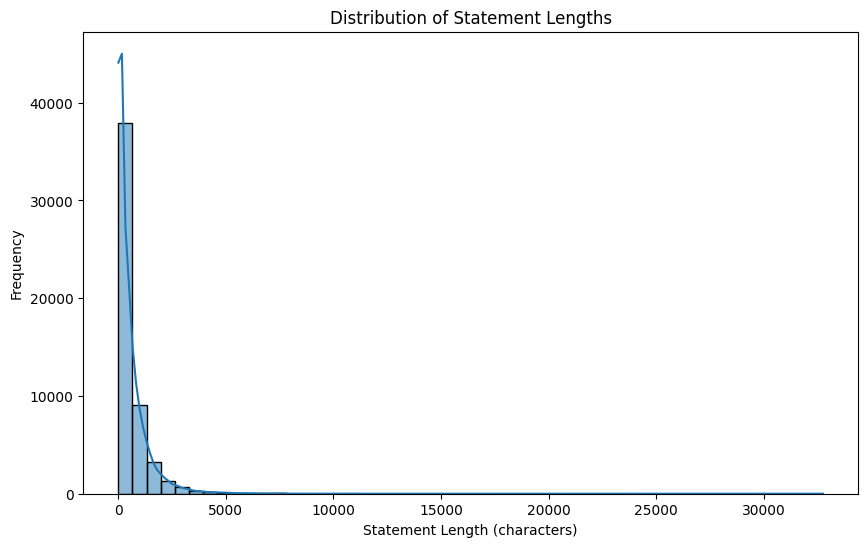

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['statement_length'], bins=50, kde=True)
plt.title('Distribution of Statement Lengths')
plt.xlabel('Statement Length (characters)')
plt.ylabel('Frequency')
plt.show()

In [11]:
import re
import nltk
from nltk.corpus import stopwords
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

df_cleaned = df.dropna(subset=['statement']).copy()
df_cleaned['cleaned_statement'] = df_cleaned['statement'].apply(clean_text)

max_words = 10000
max_len = 100

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df_cleaned['cleaned_statement'])
sequences = tokenizer.texts_to_sequences(df_cleaned['cleaned_statement'])

word_index = tokenizer.word_index
print(f'Found {len(word_index)} unique tokens.')

X = pad_sequences(sequences, maxlen=max_len)
display(X.shape)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Found 74619 unique tokens.


(52681, 100)

In [12]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 10000
max_len = 100

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df_cleaned['cleaned_statement'])

sequences = tokenizer.texts_to_sequences(df_cleaned['cleaned_statement'])
word_index = tokenizer.word_index
X = pad_sequences(sequences, maxlen=max_len)

print(f'Unique tokens: {len(word_index)}')
print(f'Shape of data tensor: {X.shape}')

Unique tokens: 74619
Shape of data tensor: (52681, 100)


In [16]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

le = LabelEncoder()
df_cleaned['label'] = le.fit_transform(df_cleaned['status'])
num_classes = df_cleaned['label'].nunique()

model = Sequential([
    Embedding(input_dim=max_words, output_dim=64, input_length=max_len),
    SimpleRNN(64),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [25]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam

X_train, X_test, y_train, y_test = train_test_split(X, df_cleaned['label'].values, test_size=0.2, random_state=42)

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    X_train,
    y_train,
    epochs=2,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/2
659/659 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.9895 - loss: 0.0362 - val_accuracy: 0.6329 - val_loss: 2.3235
Epoch 2/2
659/659 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9932 - loss: 0.0240 - val_accuracy: 0.6488 - val_loss: 2.2711


330/330 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Accuracy_score 0.6487615070703237
                      precision    recall  f1-score   support

             Anxiety       0.61      0.66      0.63       755
             Bipolar       0.52      0.54      0.53       527
          Depression       0.59      0.61      0.60      3016
              Normal       0.88      0.84      0.86      3308
Personality disorder       0.42      0.36      0.39       237
              Stress       0.42      0.42      0.42       536
            Suicidal       0.52      0.51      0.52      2158

            accuracy                           0.65     10537
           macro avg       0.57      0.56      0.56     10537
        weighted avg       0.65      0.65      0.65     10537



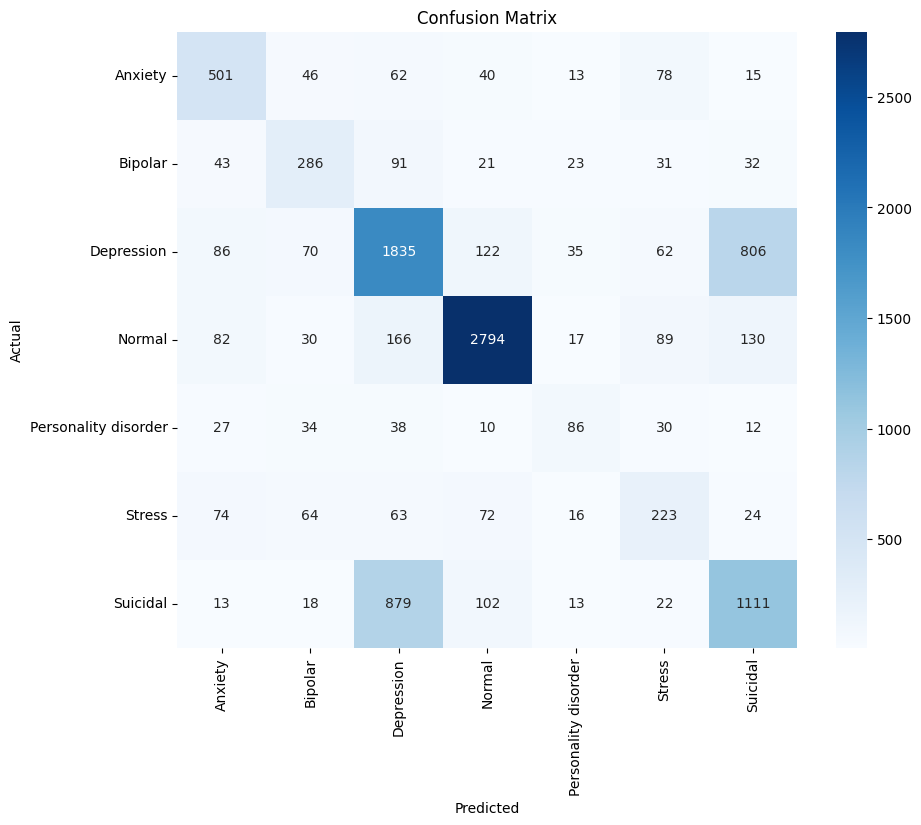

In [28]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
print(f"Accuracy_score", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()